<a href="https://colab.research.google.com/github/physom-tech/csot-ml-astronomy/blob/main/week_1_data_starter2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cpu


In [7]:
import os
import zipfile
from pathlib import Path

RAW_ROOT   = Path("galaxy_raw")
DATA_ROOT  = Path("galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"

RAW_ROOT.mkdir(exist_ok=True)

# ── FIX 1: Correct credential method for new-style token ─────────────────────
# New Kaggle tokens use KAGGLE_API_TOKEN env var, NOT access_token file
os.environ["KAGGLE_API_TOKEN"] = "KGAT_6a08d1a62a469498190fbc68ddfcf650"  # <-- paste new token
!pip -q install kaggle

# ── FIX 2: Download WITHOUT --unzip (it's unreliable), extract manually ───────
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}

# ── FIX 3: Manual extraction with Python zipfile (guaranteed to work) ─────────
outer_zip = RAW_ROOT / "galaxy-zoo-2-images.zip"

if not outer_zip.exists():
    raise FileNotFoundError(
        f"Download failed — {outer_zip} not found.\n"
        f"RAW_ROOT contains: {sorted(p.name for p in RAW_ROOT.iterdir())}"
    )

print("Extracting outer zip (this may take a minute)...")
with zipfile.ZipFile(outer_zip, "r") as z:
    z.extractall(RAW_ROOT)
print("✓ Outer zip extracted")
print("  RAW_ROOT now contains:", sorted(p.name for p in RAW_ROOT.iterdir()))

# ── Extract inner images_gz2.zip if it exists ─────────────────────────────────
inner_zip = RAW_ROOT / "images_gz2.zip"
if inner_zip.exists():
    print("Extracting images_gz2.zip...")
    (RAW_ROOT / "images_gz2").mkdir(exist_ok=True)
    with zipfile.ZipFile(inner_zip, "r") as z:
        z.extractall(RAW_ROOT / "images_gz2")
    print("✓ Inner zip extracted")
else:
    print("No inner images_gz2.zip found — JPGs should be flat in RAW_ROOT")

# ── FIX 4: Robust IMAGES_DIR finder — walks ALL subdirs, no StopIteration ─────
def find_images_dir(root: Path) -> Path:
    all_dirs = [root] + sorted(root.rglob("*/"))
    counts   = {d: sum(1 for _ in d.glob("*.jpg")) for d in all_dirs}

    print("\nJPG counts per directory:")
    for d, c in sorted(counts.items(), key=lambda x: -x[1])[:5]:
        print(f"  {c:>6,}  {d}")

    best  = max(counts, key=counts.get)
    count = counts[best]

    if count == 0:
        raise RuntimeError(
            f"No .jpg files found anywhere under {root}\n"
            f"Extraction may have failed. Contents: {sorted(p.name for p in root.iterdir())}"
        )
    return best

IMAGES_DIR = find_images_dir(RAW_ROOT)
print(f"\n✓ JPGs found in : {IMAGES_DIR}")
print(f"✓ JPG count     : {sum(1 for _ in IMAGES_DIR.glob('*.jpg')):,}")

# ── Download Hart et al. labels ───────────────────────────────────────────────
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz
print("\n✓ Labels CSV ready")
print("✓ RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
print("  RAW_ROOT   =", RAW_ROOT)
print("  IMAGES_DIR =", IMAGES_DIR)
print("  DATA_ROOT  =", DATA_ROOT)

Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:45<00:00, 72.1MB/s]

Extracting outer zip (this may take a minute)...
✓ Outer zip extracted
  RAW_ROOT now contains: ['galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv', 'images_gz2']
No inner images_gz2.zip found — JPGs should be flat in RAW_ROOT

JPG counts per directory:
  243,434  galaxy_raw/images_gz2/images
       0  galaxy_raw
       0  galaxy_raw/images_gz2

✓ JPGs found in : galaxy_raw/images_gz2/images
✓ JPG count     : 243,434

✓ Labels CSV ready
✓ RAW_ROOT contents: ['galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
  RAW_ROOT   = galaxy_raw
  IMAGES_DIR = galaxy_raw/images_gz2/images
  DATA_ROOT  = galaxy_data


In [8]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

print("\nMapping CSV preview:")
print(pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3))

print("\nLabels CSV preview (note dr7objid — we rename to objid before merging):")
print(pd.read_csv(RAW_ROOT / "gz2_hart16.csv", nrows=3)[["dr7objid", "gz2_class"]])

RAW_ROOT contents: ['galaxy-zoo-2-images.zip', 'gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434

Mapping CSV preview:
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3

Labels CSV preview (note dr7objid — we rename to objid before merging):
             dr7objid gz2_class
0  587732591714893851      Sc+t
1  588009368545984617      Sb+t
2  587732484359913515        Ei


In [9]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 codes (Sc2t, Ei, SBb2m, …) to a few training buckets."""
    if not isinstance(gz2_class, str) or gz2_class == "A":
        return None  # artifact / ambiguous
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def load_labeled_table(mapping_csv, labels_csv):
    """Join Kaggle mapping (objid ↔ asset_id) with Hart et al. morphology labels."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv)
    if "dr7objid" in labels.columns:
        labels = labels.rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"]).reset_index(drop=True)
    return df


def _link_image(src: Path, dst: Path) -> bool:
    """Symlink if possible; otherwise copy (some Drive setups block symlinks)."""
    if dst.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except OSError:
        import shutil
        shutil.copy2(src, dst)
    return True


def build_split_imagefolder_layout(
    images_dir,
    df,
    out_root,
    per_class=200,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
):
    """Create out_root/{train,val,test}//*.jpg for ImageFolder."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    images_dir = Path(images_dir)
    out_root = Path(out_root)
    summary = {}

    for label in sorted(df["label"].unique()):
        rows = df[df["label"] == label].sample(frac=1, random_state=seed)
        if len(rows) > per_class:
            rows = rows.head(per_class)

        n = len(rows)
        n_train = int(train_frac * n)
        n_val = int(val_frac * n)
        n_test = n - n_train - n_val
        splits = {
            "train": rows.iloc[:n_train],
            "val": rows.iloc[n_train : n_train + n_val],
            "test": rows.iloc[n_train + n_val :],
        }

        summary[label] = {}
        for split_name, split_rows in splits.items():
            linked = 0
            for _, row in split_rows.iterrows():
                src = images_dir / f"{int(row.asset_id)}.jpg"
                dst = out_root / split_name / label / f"{int(row.asset_id)}.jpg"
                if src.exists() and _link_image(src, dst):
                    linked += 1
            summary[label][split_name] = linked
    return summary

df = load_labeled_table(
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
)
print("Joined rows:", len(df))
print("\nLabel counts:")
print(df["label"].value_counts())
print("\nExample rows:")
print(df[["asset_id", "objid", "gz2_class", "label"]].head())

Joined rows: 239100

Label counts:
label
elliptical       97670
spiral           95849
spiral_barred    45581
Name: count, dtype: int64

Example rows:
   asset_id               objid gz2_class       label
0         3  587722981741363294        Sb      spiral
1         4  587722981741363323      Sc?l      spiral
2         5  587722981741559888        Er  elliptical
3         6  587722981741625481      Sc1t      spiral
4         7  587722981741625484        Sb      spiral


In [10]:
PER_CLASS = 200  # increase once the pipeline works (e.g. 2000)

summary = build_split_imagefolder_layout(
    IMAGES_DIR,
    df,
    DATA_ROOT,
    per_class=PER_CLASS,
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    seed=42,
)
print("Linked images per class and split:")
print(pd.DataFrame(summary).fillna(0).astype(int))

for split in ("train", "val", "test"):
    split_dir = DATA_ROOT / split
    classes = sorted(p.name for p in split_dir.iterdir() if p.is_dir()) if split_dir.exists() else []
    n_imgs = sum(1 for _ in split_dir.rglob("*.jpg")) if split_dir.exists() else 0
    print(f"{split:5s}: {n_imgs:4d} images  classes={classes}")

Linked images per class and split:
       elliptical  spiral  spiral_barred
train         140     140            140
val            30      30             30
test           30      30             30
train:  420 images  classes=['elliptical', 'spiral', 'spiral_barred']
val  :   90 images  classes=['elliptical', 'spiral', 'spiral_barred']
test :   90 images  classes=['elliptical', 'spiral', 'spiral_barred']


In [11]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [12]:
train_ds = ImageFolder(root=DATA_ROOT / "train", transform=transform)
val_ds   = ImageFolder(root=DATA_ROOT / "val",   transform=transform)
test_ds  = ImageFolder(root=DATA_ROOT / "test",  transform=transform)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    print(f"{name:5s}  n={len(ds):4d}  classes={ds.classes}")

print("class_to_idx:", train_ds.class_to_idx)

train  n= 420  classes=['elliptical', 'spiral', 'spiral_barred']
val    n=  90  classes=['elliptical', 'spiral', 'spiral_barred']
test   n=  90  classes=['elliptical', 'spiral', 'spiral_barred']
class_to_idx: {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


In [13]:
image, label = train_ds[0]
print("shape :", image.shape)
print("dtype :", image.dtype)
print("label :", label, "->", train_ds.classes[label])


shape : torch.Size([3, 64, 64])
dtype : torch.float32
label : 0 -> elliptical


In [14]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print("train batch images:", images.shape)   # (32, 3, 64, 64)
print("train batch labels:", labels.shape)     # (32,)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


train batch images: torch.Size([32, 3, 64, 64])
train batch labels: torch.Size([32])


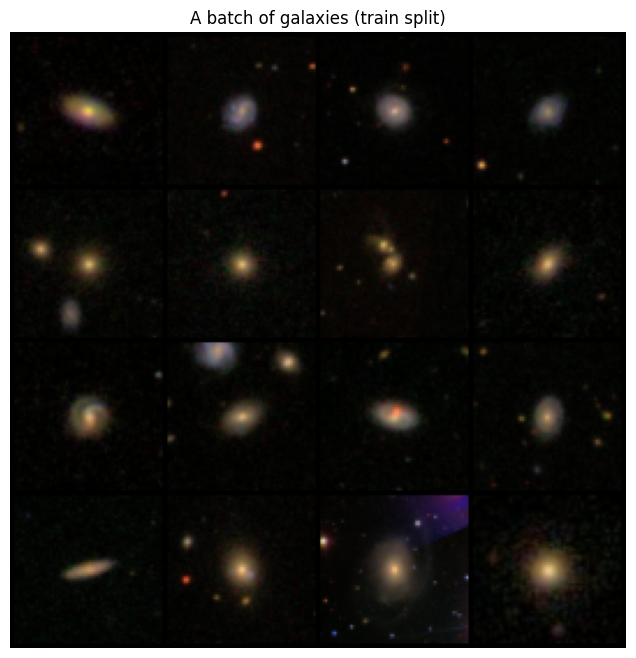

Labels: ['spiral', 'spiral_barred', 'spiral', 'spiral_barred', 'elliptical', 'elliptical', 'spiral', 'spiral', 'spiral_barred', 'spiral_barred', 'spiral_barred', 'spiral', 'spiral_barred', 'elliptical', 'elliptical', 'elliptical']


In [15]:
images_show = images * 0.5 + 0.5
grid = torchvision.utils.make_grid(images_show[:16], nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("A batch of galaxies (train split)")
plt.show()

print("Labels:", [train_ds.classes[i] for i in labels[:16].tolist()])

In [16]:
stat_ds = ImageFolder(
    root=DATA_ROOT / "train",
    transform=transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()]),
)
stat_loader = DataLoader(stat_ds, batch_size=64, shuffle=False, num_workers=2)

n_pixels = 0
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
for imgs, _ in stat_loader:
    channel_sum += imgs.sum(dim=[0, 2, 3])
    channel_sq_sum += (imgs ** 2).sum(dim=[0, 2, 3])
    n_pixels += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]

mean = channel_sum / n_pixels
std = (channel_sq_sum / n_pixels - mean ** 2).sqrt()
print("per-channel mean:", mean.tolist())
print("per-channel std :", std.tolist())


per-channel mean: [0.045792024582624435, 0.040187980979681015, 0.029950125142931938]
per-channel std : [0.08739043027162552, 0.07174350321292877, 0.06345327198505402]


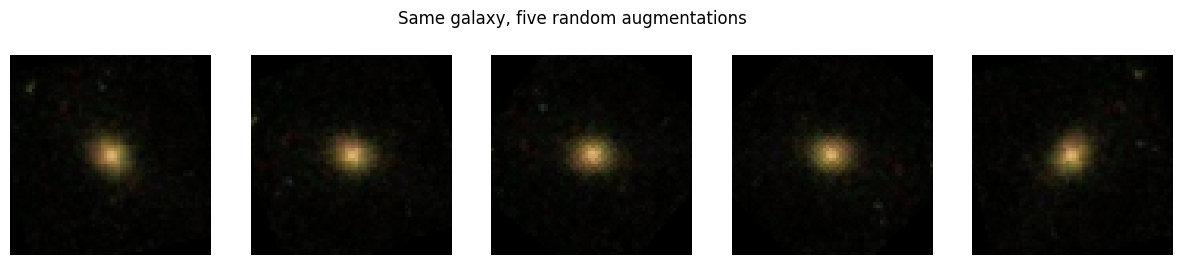

In [17]:
aug = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
])

img_path, _ = train_ds.samples[0]
from PIL import Image
pil_img = Image.open(img_path).convert("RGB")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    ax.imshow(aug(pil_img).permute(1, 2, 0).numpy())
    ax.axis("off")
fig.suptitle("Same galaxy, five random augmentations")
plt.show()